# Financed TIPS Trade

Direct `fuggers` walk-through of a financed 5Y TIPS trade.


In [12]:
from dataclasses import replace
from decimal import Decimal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fuggers_py.core import Compounding, Currency, Date, Frequency, Price, YearMonth, Yield
from fuggers_py.core.calendars import BusinessDayConvention
from fuggers_py.core.daycounts import DayCountConvention
from fuggers_py.market.snapshot import InflationFixing as InflationFixingPoint
from fuggers_py.market.sources import InMemoryInflationFixingSource
# Public curve imports now start at fuggers_py.curves.
from fuggers_py.curves import YieldCurve
# This notebook still needs a later full rewrite for the current funding and inflation curve helpers.
from fuggers_py.funding import repo_carry_return, repo_financing_cost, repo_net_carry
from fuggers_py.inflation import breakeven_inflation_rate
from fuggers_py.bonds import BondRiskCalculator, dv01_hedge_ratio
from fuggers_py.bonds import BondPricer, TipsPricer
from fuggers_py.bonds import FixedBondBuilder, TipsBond
from fuggers_py.funding import RepoTrade
from fuggers_py.rates import PayReceive, ZeroCouponInflationSwap
from fuggers_py.reference import Tenor, YieldCalculationRules
from fuggers_py.reference.bonds.types import CalendarId, SettlementAdjustment
from fuggers_py.inflation import USD_CPI_U_NSA

pd.set_option('display.max_columns', 16)
pd.set_option('display.width', 180)


def dec(value: object) -> Decimal:
    return value if isinstance(value, Decimal) else Decimal(str(value))


def pct(value: Decimal | None, digits: int = 2) -> str:
    return '' if value is None else f"{100.0 * float(value):.{digits}f}%"


def money(value: Decimal | None, digits: int = 0) -> str:
    return '' if value is None else f"${float(value):,.{digits}f}"


## 1. Setup

Fix the trade pair, prices, and main assumptions.


In [13]:
cash_bond_quotes = pd.read_csv('synthetic_data/bonds/cash_bond_market_levels.csv').set_index('instrument_id')
nominal_curve_quotes = pd.read_csv('synthetic_data/curves/nominal_government_curve.csv')
real_curve_quotes = pd.read_csv('synthetic_data/curves/real_rate_curve.csv')
discount_curve_quotes = pd.read_csv('synthetic_data/curves/ois_discount_curve.csv')
funding_curve_quotes = pd.read_csv('synthetic_data/curves/repo_funding_curve.csv')
inflation_swap_quotes = pd.read_csv('synthetic_data/curves/inflation_swap_curve.csv')
cash_breakeven_quotes = pd.read_csv('synthetic_data/curves/cash_breakeven_markers.csv')
realized_cpi = pd.read_csv('synthetic_data/inflation/realized_cpi.csv')

trade_date = Date.parse('2026-01-15')
tips_id = 'TIPS_5Y_2031'
hedge_id = 'UST_5Y_2031'
tips_issue_date = Date.parse('2024-01-15')
tips_maturity_date = Date.parse('2031-01-15')
tips_coupon_rate = Decimal('0.0125')
hedge_issue_date = Date.parse('2024-01-15')
hedge_maturity_date = Date.parse('2031-01-15')
hedge_coupon_rate = Decimal('0.0375')
trade_notional = Decimal('25000000')
repo_haircut = Decimal('0.02')
carry_horizon_months = 3
cpi_surprise_month = '2026-04'

tips_clean_price = dec(cash_bond_quotes.at[tips_id, 'value'])
hedge_clean_price = dec(cash_bond_quotes.at[hedge_id, 'value'])

bond_rules_template = YieldCalculationRules.us_treasury()
treasury_rules = replace(
    bond_rules_template,
    frequency=Frequency.SEMI_ANNUAL,
    calendar=CalendarId.new('USGOV'),
    business_day_convention=BusinessDayConvention.MODIFIED_FOLLOWING,
    settlement_rules=replace(
        bond_rules_template.settlement_rules,
        days=1,
        adjustment=SettlementAdjustment.MODIFIED_FOLLOWING,
    ),
    accrual_day_count=DayCountConvention.ACT_ACT_ICMA,
    yield_day_count=DayCountConvention.ACT_ACT_ICMA,
    discount_day_count=DayCountConvention.ACT_ACT_ICMA,
)

tips_settlement_date = treasury_rules.settlement_rules.settlement_date(trade_date, treasury_rules.calendar.to_calendar())
hedge_settlement_date = treasury_rules.settlement_rules.settlement_date(trade_date, treasury_rules.calendar.to_calendar())
observed_realized_cpi_rows = [
    row
    for row in realized_cpi.to_dict('records')
    if Date.parse(row['publication_date']) <= trade_date
]

setup_table = pd.DataFrame(
    [
        {
            'trade_date': str(trade_date),
            'tips_id': tips_id,
            'hedge_id': hedge_id,
            'tips_clean': f"{float(tips_clean_price):.2f}",
            'hedge_clean': f"{float(hedge_clean_price):.2f}",
            'notional': money(trade_notional),
            'horizon': f'{carry_horizon_months}M',
            'repo_haircut': pct(repo_haircut),
            'cpi_shock_month': cpi_surprise_month,
        }
    ]
)

setup_table


,trade_date,tips_id,hedge_id,tips_clean,hedge_clean,notional,horizon,repo_haircut,cpi_shock_month
0,2026-01-15,TIPS_5Y_2031,UST_5Y_2031,103.45,99.14,"$25,000,000",3M,2.00%,2026-04


## 2. Build Market Objects

Build the curves and the CPI path used to price the trade.


In [14]:
realized_cpi_history = [
    InflationFixingPoint(
        'CPURNSA',
        YearMonth.parse(row['realized_month']),
        dec(row['index_value']),
        publication_date=Date.parse(row['publication_date']),
    )
    for row in observed_realized_cpi_rows
]

if not realized_cpi_history:
    raise ValueError('The notebook needs at least one published CPI print on or before the trade date.')

last_observed_year_month = realized_cpi_history[-1].observation_month
cpi_surprise_year_month = YearMonth.parse(cpi_surprise_month)
if (cpi_surprise_year_month.year, cpi_surprise_year_month.month) <= (last_observed_year_month.year, last_observed_year_month.month):
    raise ValueError('The CPI surprise month must be after the last realized CPI month.')

curve_objects = []
for quotes in [nominal_curve_quotes, real_curve_quotes, discount_curve_quotes, funding_curve_quotes]:
    builder = DiscountCurveBuilder(reference_date=tips_settlement_date)
    for row in quotes.itertuples(index=False):
        builder = builder.add_zero_rate(Tenor.parse(row.tenor).to_years_approx(), dec(row.value))
    curve_objects.append(builder.build())

nominal_curve, real_curve, discount_curve, funding_curve = curve_objects
repo_curve = RepoCurve.of(funding_curve)


def project_cpi_source(cpi_surprise_size: Decimal = Decimal('0')):
    inflation_swaps = []
    for row in inflation_swap_quotes.itertuples(index=False):
        years = int(row.tenor[:-1])
        inflation_swaps.append(
            ZeroCouponInflationSwap.new(
                trade_date=trade_date,
                effective_date=tips_settlement_date,
                maturity_date=tips_settlement_date.add_years(years),
                notional=Decimal('1000000'),
                fixed_rate=(Decimal(1) + dec(row.value)) ** Decimal(years) - Decimal(1),
                pay_receive=PayReceive.PAY,
                currency=Currency.USD,
                inflation_convention=USD_CPI_U_NSA,
                instrument_id=row.instrument_id,
            )
        )

    inflation_curve = bootstrap_inflation_curve(
        inflation_swaps,
        fixing_source=InMemoryInflationFixingSource(realized_cpi_history),
        discount_curve=discount_curve,
    ).curve

    projected_cpi_history = []
    current_month_start = Date.from_ymd(last_observed_year_month.year, last_observed_year_month.month, 1).add_months(1)
    final_month_start = tips_maturity_date.start_of_month().add_months(1)
    while (current_month_start.year(), current_month_start.month()) <= (final_month_start.year(), final_month_start.month()):
        current_year_month = YearMonth(current_month_start.year(), current_month_start.month())
        projected_value = inflation_curve.projected_reference_cpi(
            current_month_start.add_months(USD_CPI_U_NSA.observation_lag_months)
        )
        if str(current_year_month) == cpi_surprise_month:
            projected_value += cpi_surprise_size
        projected_cpi_history.append(InflationFixingPoint('CPURNSA', current_year_month, projected_value))
        current_month_start = current_month_start.add_months(1)

    return InMemoryInflationFixingSource([*realized_cpi_history, *projected_cpi_history]), inflation_curve


pricing_cpi_source, inflation_curve = project_cpi_source()


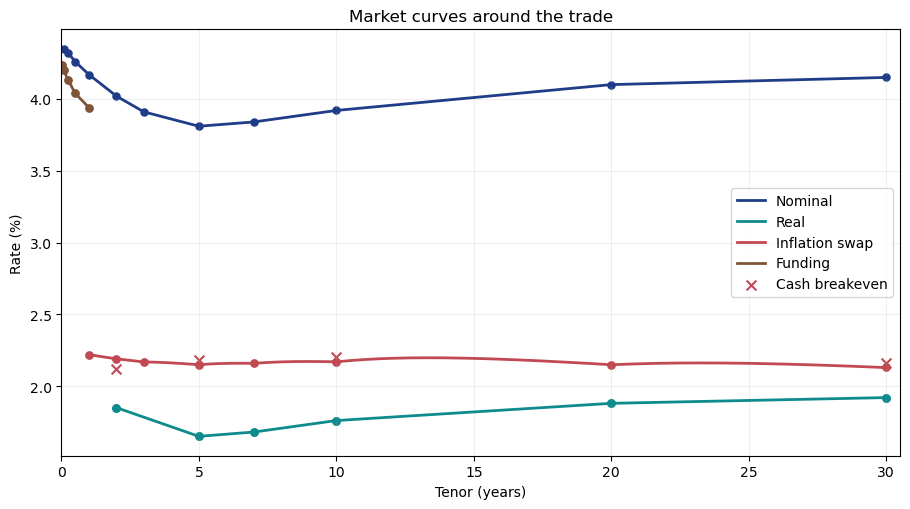

In [15]:
figure, axis = plt.subplots(figsize=(9.2, 5.2))

nominal_grid = np.linspace(0.1, 30.0, 240)
real_grid = np.linspace(2.0, 30.0, 180)
inflation_grid = np.linspace(1.0, 30.0, 180)
funding_grid = np.linspace(1.0 / 52.0, 1.0, 60)

nominal_curve_line = [100.0 * float(nominal_curve.zero_rate(tips_settlement_date.add_days(int(round(365 * years)))).value()) for years in nominal_grid]
real_curve_line = [100.0 * float(real_curve.zero_rate(tips_settlement_date.add_days(int(round(365 * years)))).value()) for years in real_grid]
inflation_curve_line = [100.0 * float(inflation_curve.zero_inflation_rate(tips_settlement_date, tips_settlement_date.add_days(int(round(365 * years))))) for years in inflation_grid]
funding_curve_line = [100.0 * float(funding_curve.zero_rate(tips_settlement_date.add_days(int(round(365 * years)))).value()) for years in funding_grid]

axis.plot(nominal_grid, nominal_curve_line, linewidth=2.0, color='#1f3c88', label='Nominal')
axis.plot(real_grid, real_curve_line, linewidth=2.0, color='#0f8b8d', label='Real')
axis.plot(inflation_grid, inflation_curve_line, linewidth=2.0, color='#c14953', label='Inflation swap')
axis.plot(funding_grid, funding_curve_line, linewidth=2.0, color='#7f5539', label='Funding')
axis.scatter([Tenor.parse(row.tenor).to_years_approx() for row in nominal_curve_quotes.itertuples(index=False)], [100.0 * float(dec(row.value)) for row in nominal_curve_quotes.itertuples(index=False)], color='#1f3c88', s=26)
axis.scatter([Tenor.parse(row.tenor).to_years_approx() for row in real_curve_quotes.itertuples(index=False)], [100.0 * float(dec(row.value)) for row in real_curve_quotes.itertuples(index=False)], color='#0f8b8d', s=30)
axis.scatter([Tenor.parse(row.tenor).to_years_approx() for row in inflation_swap_quotes.itertuples(index=False)], [100.0 * float(dec(row.value)) for row in inflation_swap_quotes.itertuples(index=False)], color='#c14953', s=28)
axis.scatter([Tenor.parse(row.tenor).to_years_approx() for row in funding_curve_quotes.itertuples(index=False)], [100.0 * float(dec(row.value)) for row in funding_curve_quotes.itertuples(index=False)], color='#7f5539', s=28)
axis.scatter([Tenor.parse(row.tenor).to_years_approx() for row in cash_breakeven_quotes.itertuples(index=False)], [100.0 * float(dec(row.value)) for row in cash_breakeven_quotes.itertuples(index=False)], color='#c14953', marker='x', s=50, label='Cash breakeven')

axis.set_title('Market curves around the trade')
axis.set_xlabel('Tenor (years)')
axis.set_ylabel('Rate (%)')
axis.set_xlim(0, 30.5)
axis.grid(alpha=0.2)
axis.legend(title='')
plt.tight_layout()
plt.show()


## 3. Linker Mechanics

Show the CPI months and indexation that feed the TIPS invoice.


In [16]:
bond_pricer = BondPricer()
tips_pricer = TipsPricer()

tips_bond = TipsBond.new(
    issue_date=tips_issue_date,
    dated_date=tips_issue_date,
    maturity_date=tips_maturity_date,
    coupon_rate=tips_coupon_rate,
    inflation_convention=USD_CPI_U_NSA,
    base_reference_date=tips_issue_date,
    frequency=Frequency.SEMI_ANNUAL,
    currency=Currency.USD,
    rules=treasury_rules,
    fixing_source=pricing_cpi_source,
)
hedge_bond = (
    FixedBondBuilder.new()
    .with_issue_date(hedge_issue_date)
    .with_maturity_date(hedge_maturity_date)
    .with_coupon_rate(hedge_coupon_rate)
    .with_frequency(Frequency.SEMI_ANNUAL)
    .with_currency(Currency.USD)
    .with_notional(Decimal('100'))
    .with_rules(treasury_rules)
    .build()
)
carry_horizon_date = tips_settlement_date.add_months(carry_horizon_months)

curve_real_yield = real_curve.zero_rate(tips_bond.maturity_date()).value()
curve_nominal_yield = nominal_curve.zero_rate(hedge_bond.maturity_date()).value()
curve_real_yield_obj = Yield.new(curve_real_yield, Compounding.SEMI_ANNUAL)
hedge_market_yield_obj = bond_pricer.yield_from_price(
    hedge_bond,
    Price.new(hedge_clean_price, Currency.USD),
    hedge_settlement_date,
).ytm
hedge_market_yield = hedge_market_yield_obj.value()

tips_curve_price = tips_pricer.price_from_real_yield(tips_bond, curve_real_yield_obj, tips_settlement_date)
next_coupon_flow = tips_bond.projected_coupon_cash_flows(
    fixing_source=pricing_cpi_source,
    settlement_date=tips_settlement_date,
)[0]

linker_rows = []
for label, date in [('Settlement', tips_settlement_date), (f'{carry_horizon_months}M horizon', carry_horizon_date), ('Next coupon', next_coupon_flow.date)]:
    lag_month_1_date = date.start_of_month().add_months(-USD_CPI_U_NSA.observation_lag_months)
    lag_month_2_date = date.start_of_month().add_months(1 - USD_CPI_U_NSA.observation_lag_months)
    lag_month_1 = YearMonth(lag_month_1_date.year(), lag_month_1_date.month())
    lag_month_2 = YearMonth(lag_month_2_date.year(), lag_month_2_date.month())
    row = {
        'event': label,
        'date': str(date),
        'reference_months': f'{lag_month_1} / {lag_month_2}',
        'source_mix': (
            f"{'obs' if (lag_month_1.year, lag_month_1.month) <= (last_observed_year_month.year, last_observed_year_month.month) else 'proj'}"
            f" / {'obs' if (lag_month_2.year, lag_month_2.month) <= (last_observed_year_month.year, last_observed_year_month.month) else 'proj'}"
        ),
        'reference_cpi': f"{float(tips_bond.reference_cpi(date, fixing_source=pricing_cpi_source)):.4f}",
        'index_ratio': '',
        'adjusted_principal_per_100': '',
        'cash_flow_per_100': '',
    }
    if label != 'Next coupon':
        index_ratio = tips_bond.index_ratio(date, fixing_source=pricing_cpi_source)
        row['index_ratio'] = f"{float(index_ratio):.6f}"
        row['adjusted_principal_per_100'] = f"{float(tips_bond.adjusted_principal(date, fixing_source=pricing_cpi_source)):.4f}"
    if label == 'Settlement':
        row['cash_flow_per_100'] = f"{float(tips_bond.accrued_interest(date) * tips_bond.index_ratio(date, fixing_source=pricing_cpi_source)):.4f}"
    if label == 'Next coupon':
        row['cash_flow_per_100'] = f"{float(next_coupon_flow.factored_amount()):.4f}"
    linker_rows.append(row)

linker_table = pd.DataFrame(linker_rows)
linker_table


,event,date,reference_months,source_mix,reference_cpi,index_ratio,adjusted_principal_per_100,cash_flow_per_100
0,Settlement,2026-01-16,2025-10 / 2025-11,obs / obs,312.1065,1.028207,102.8207,0.6608
1,3M horizon,2026-04-16,2026-01 / 2026-02,proj / proj,313.8149,1.033835,103.3835,
2,Next coupon,2026-07-15,2026-04 / 2026-05,proj / proj,315.5234,,,0.6497


## 4. Breakeven

Compare cash breakevens with the curve view and the swap curve.


In [17]:
tips_street_real_yield = tips_pricer.real_yield_from_clean_price(
    tips_bond,
    Price.new(tips_clean_price, Currency.USD),
    tips_settlement_date,
).ytm.value()

trade_cash_breakeven = breakeven_inflation_rate(
    nominal_yield=hedge_market_yield,
    real_yield=tips_street_real_yield,
)
trade_curve_breakeven = breakeven_inflation_rate(
    nominal_yield=curve_nominal_yield,
    real_yield=curve_real_yield,
)
trade_swap_breakeven = inflation_curve.zero_inflation_rate(tips_settlement_date, tips_bond.maturity_date())

breakeven_rows = [
    {
        'tenor': 'Trade pair',
        'real_yield': pct(tips_street_real_yield),
        'cash_breakeven': pct(trade_cash_breakeven),
        'curve_breakeven': pct(trade_curve_breakeven),
        'swap_breakeven': pct(trade_swap_breakeven),
        'cash_minus_swap_bp': f"{10000.0 * float(trade_cash_breakeven - trade_swap_breakeven):.1f}",
    }
]
for row in cash_breakeven_quotes.itertuples(index=False):
    maturity_date = Tenor.parse(row.tenor).add_to(tips_settlement_date)
    curve_real_yield_at_tenor = real_curve.zero_rate(maturity_date).value()
    curve_breakeven = breakeven_inflation_rate(
        nominal_yield=nominal_curve.zero_rate(maturity_date).value(),
        real_yield=curve_real_yield_at_tenor,
    )
    swap_breakeven = inflation_curve.zero_inflation_rate(tips_settlement_date, maturity_date)
    breakeven_rows.append(
        {
            'tenor': row.tenor,
            'real_yield': pct(curve_real_yield_at_tenor),
            'cash_breakeven': pct(dec(row.value)),
            'curve_breakeven': pct(curve_breakeven),
            'swap_breakeven': pct(swap_breakeven),
            'cash_minus_swap_bp': f"{10000.0 * float(dec(row.value) - swap_breakeven):.1f}",
        }
    )

breakeven_table = pd.DataFrame(breakeven_rows)
breakeven_table


,tenor,real_yield,cash_breakeven,curve_breakeven,swap_breakeven,cash_minus_swap_bp
0,Trade pair,32.82%,-21.75%,2.12%,2.15%,-2389.4
1,2Y,1.85%,2.12%,2.13%,2.19%,-7.0
2,5Y,1.65%,2.18%,2.12%,2.15%,3.1
3,10Y,1.76%,2.20%,2.12%,2.17%,3.1
4,30Y,1.92%,2.16%,2.19%,2.13%,3.1


## 5. Carry And Roll

Break the financed P&L into carry, accretion, rolldown, and repo drag.


In [18]:
remaining_days = carry_horizon_date.days_between(tips_bond.maturity_date())
rolled_real_yield = real_curve.zero_rate(tips_settlement_date.add_days(remaining_days)).value()
repo_forward_rate = repo_curve.forward_rate(tips_settlement_date, carry_horizon_date)
trade_units = trade_notional / Decimal(100)

rolled_real_yield_obj = Yield.new(rolled_real_yield, Compounding.SEMI_ANNUAL)
horizon_tips_price = tips_pricer.price_from_real_yield(tips_bond, rolled_real_yield_obj, carry_horizon_date)
settlement_index_ratio = tips_bond.index_ratio(tips_settlement_date, fixing_source=pricing_cpi_source)
horizon_index_ratio = tips_bond.index_ratio(carry_horizon_date, fixing_source=pricing_cpi_source)
settlement_invoice_dirty = tips_curve_price.dirty.as_percentage() * settlement_index_ratio
horizon_invoice_dirty = horizon_tips_price.dirty.as_percentage() * horizon_index_ratio
settlement_adjusted_accrued = tips_bond.accrued_interest(tips_settlement_date) * settlement_index_ratio
horizon_adjusted_accrued = tips_bond.accrued_interest(carry_horizon_date) * horizon_index_ratio

gross_price_carry = (horizon_invoice_dirty - settlement_invoice_dirty) * trade_units
coupon_carry = (horizon_adjusted_accrued - settlement_adjusted_accrued) * trade_units
inflation_accretion = (
    tips_bond.adjusted_principal(carry_horizon_date, fixing_source=pricing_cpi_source)
    - tips_bond.adjusted_principal(tips_settlement_date, fixing_source=pricing_cpi_source)
) * trade_units
rolldown_pull_to_par = gross_price_carry - coupon_carry - inflation_accretion

repo_trade = RepoTrade(
    start_date=tips_settlement_date,
    end_date=carry_horizon_date,
    rate=repo_forward_rate,
    collateral_price=settlement_invoice_dirty,
    haircut=repo_haircut,
    notional=trade_notional,
    currency=Currency.USD,
)
funding_cost = repo_financing_cost(repo_trade)
net_financed_carry = repo_net_carry(repo_trade, collateral_income=gross_price_carry)
carry_return = repo_carry_return(repo_trade, collateral_income=gross_price_carry)

carry_table = pd.DataFrame(
    [
        {
            'repo_forward_rate': pct(repo_forward_rate),
            'coupon_carry': money(coupon_carry),
            'inflation_accretion': money(inflation_accretion),
            'rolldown': money(rolldown_pull_to_par),
            'gross_price_carry': money(gross_price_carry),
            'funding_cost': money(funding_cost),
            'net_financed_carry': money(net_financed_carry),
            'return_bp': f"{10000.0 * float(carry_return):.1f}",
        }
    ]
)

carry_table


,repo_forward_rate,coupon_carry,inflation_accretion,rolldown,gross_price_carry,funding_cost,net_financed_carry,return_bp
0,4.10%,"$1,813","$140,709","$24,057","$166,579","$310,000","$-143,420",-47.4


## 6. Hedge And Scenarios

Size the hedge and shock the main risks that remain.


In [19]:
tips_risk = tips_pricer.risk_metrics_from_real_yield(tips_bond, curve_real_yield_obj, tips_settlement_date)
tips_dv01 = tips_risk.dv01 * settlement_index_ratio
hedge_risk = BondRiskCalculator(
    bond=hedge_bond,
    ytm=hedge_market_yield_obj,
    settlement_date=hedge_settlement_date,
).all_metrics()
hedge_ratio = dv01_hedge_ratio(tips_dv01, hedge_risk.dv01)

parallel_rate_bps = Decimal('15')
breakeven_bps = Decimal('10')
repo_bps = Decimal('5')
cpi_surprise = Decimal('0.4')
parallel_real_shift = parallel_rate_bps / Decimal(10000)
breakeven_shift = breakeven_bps / Decimal(10000)
repo_shift = repo_bps / Decimal(10000)

base_tips_dirty = tips_curve_price.dirty.as_percentage() * settlement_index_ratio
base_hedge_dirty = bond_pricer.price_from_yield(hedge_bond, hedge_market_yield_obj, hedge_settlement_date).dirty.as_percentage()

real_yield_up_dirty = tips_pricer.price_from_real_yield(
    tips_bond,
    Yield.new(curve_real_yield + parallel_real_shift, Compounding.SEMI_ANNUAL),
    tips_settlement_date,
).dirty.as_percentage() * settlement_index_ratio
hedge_yield_up_dirty = bond_pricer.price_from_yield(
    hedge_bond,
    Yield.new(hedge_market_yield + parallel_real_shift, Compounding.SEMI_ANNUAL),
    hedge_settlement_date,
).dirty.as_percentage()
real_yield_net_pnl = (real_yield_up_dirty - base_tips_dirty - hedge_ratio * (hedge_yield_up_dirty - base_hedge_dirty)) * trade_units

scenario_rows = [
    {
        'scenario': 'Hedge ratio',
        'net_trade_pnl': '',
        'note': f'Short {hedge_id} at about {float(hedge_ratio):.2f}x per 100 par. Residual dv01 per 100 is {float(tips_dv01 - hedge_ratio * hedge_risk.dv01):.6f}.',
    },
    {
        'scenario': f'Real yield +{int(parallel_rate_bps)}bp',
        'net_trade_pnl': money(real_yield_net_pnl),
        'note': 'The hedge removes most of the parallel duration move.',
    },
]

for label, shifted_real_yield in [('Breakeven widen', curve_real_yield - breakeven_shift), ('Breakeven tighten', curve_real_yield + breakeven_shift)]:
    shifted_dirty = tips_pricer.price_from_real_yield(
        tips_bond,
        Yield.new(shifted_real_yield, Compounding.SEMI_ANNUAL),
        tips_settlement_date,
    ).dirty.as_percentage() * settlement_index_ratio
    scenario_rows.append(
        {
            'scenario': f'{label} {int(abs(breakeven_bps))}bp',
            'net_trade_pnl': money((shifted_dirty - base_tips_dirty) * trade_units),
            'note': 'Breakeven moves stay with the linker leg.',
        }
    )

surprise_cpi_source, _ = project_cpi_source(cpi_surprise_size=cpi_surprise)
surprise_horizon_index_ratio = tips_bond.index_ratio(carry_horizon_date, fixing_source=surprise_cpi_source)
base_horizon_dirty = horizon_tips_price.dirty.as_percentage() * horizon_index_ratio
surprise_horizon_dirty = horizon_tips_price.dirty.as_percentage() * surprise_horizon_index_ratio
scenario_rows.append(
    {
        'scenario': f'Projected CPI {cpi_surprise_month} +{float(cpi_surprise):.1f}',
        'net_trade_pnl': money((surprise_horizon_dirty - base_horizon_dirty) * trade_units),
        'note': 'A higher projected CPI month lifts the financed invoice by the horizon.',
    }
)

shocked_repo_trade = RepoTrade(
    start_date=tips_settlement_date,
    end_date=carry_horizon_date,
    rate=repo_forward_rate + repo_shift,
    collateral_price=settlement_invoice_dirty,
    haircut=repo_haircut,
    notional=trade_notional,
    currency=Currency.USD,
)
repo_shock_pnl = -(repo_financing_cost(shocked_repo_trade) - funding_cost)
scenario_rows.append(
    {
        'scenario': f'Repo +{int(repo_bps)}bp',
        'net_trade_pnl': money(repo_shock_pnl),
        'note': 'Funding stress hurts even if the market view is right.',
    }
)

scenario_table = pd.DataFrame(scenario_rows)
scenario_table


,scenario,net_trade_pnl,note
0,Hedge ratio,,Short UST_5Y_2031 at about 0.14x per 100 par. ...
1,Real yield +15bp,$-73,The hedge removes most of the parallel duratio...
2,Breakeven widen 10bp,"$15,328",Breakeven moves stay with the linker leg.
3,Breakeven tighten 10bp,"$-15,313",Breakeven moves stay with the linker leg.
4,Projected CPI 2026-04 +0.4,$0,A higher projected CPI month lifts the finance...
5,Repo +5bp,"$-3,784",Funding stress hurts even if the market view i...


## 7. Takeaway

Keep the close short.
